# Decision Policy Demo

This notebook will provide code demonstrating how to use Decision Policies as introduced in Wait! There's a Way Out. This notebook will also provide code for running the experiments in the paper. 

## 1. Imports and downloads

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [2]:
import unsloth
import os
import argparse
import sys
import glob

from functools import partial
import json
from convokit import Corpus, Forecaster, download
from convokit.forecaster.TransformerDecoderModel import TransformerDecoderModel
from convokit.forecaster.TransformerForecasterConfig import TransformerForecasterConfig
from convokit.decisionpolicy import DeferralDecisionPolicy, ThresholdDecisionPolicy, SimulationAverageDecisionPolicy, SimulationMajorityDecisionPolicy, RandomDeferralDecisionPolicy
from convokit.utterance_simulator.unslothUtteranceSimulatorModel import UnslothUtteranceSimulatorModel
from convokit.utterance_simulator.utteranceSimulator import UtteranceSimulator

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-06-27 02:07:23.753374: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-27 02:07:23.772991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782526043.796638  659512 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782526043.804470  659512 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782526043.824077  659512 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

INFO 06-27 02:07:32 [__init__.py:216] Automatically detected platform cuda.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
# Set repo root

from pathlib import Path

repo_root = Path.cwd()
while repo_root.name != "ConvoKit":
    repo_root = repo_root.parent

repo_root = str(repo_root)

In [ ]:
from pathlib import Path

base = Path(download("decisionpolicy-demo"))


In [ ]:
import re
corpus_dirs = sorted(
    corpus_dir
    for corpus_dir in base.rglob("*")
    if corpus_dir.is_dir() and (corpus_dir / "index.json").exists()
)
if not corpus_dirs:
    raise FileNotFoundError(f"no convokit corpora found under {base}")
_seed_policy_re = re.compile(r"^seed-(\d+)-(.+)$")
_test_seed_re = re.compile(r"^test-seed-(\d+)$")
corpora_all = {}
corpora = {}
for corpus_dir in corpus_dirs:
    if _test_seed_re.match(corpus_dir.name):
        corpora[corpus_dir.name] = Corpus(filename=str(corpus_dir))
        continue
    m_test = _test_seed_re.match(corpus_dir.parent.name)
    if m_test:
        corpora[f"test-seed-{m_test.group(1)}"] = Corpus(filename=str(corpus_dir))
        continue
    m = _seed_policy_re.match(corpus_dir.parent.name)
    if m and corpus_dir.name == m.group(2):
        corpora_all[f"seed-{m.group(1)}-{m.group(2)}"] = Corpus(filename=str(corpus_dir))
CORPUS_POLICY_PER_SEED = "DeferralDecisionPolicy"
if not corpora:
    for key in sorted(corpora_all):
        m = _seed_policy_re.match(key)
        if m and m.group(2) == CORPUS_POLICY_PER_SEED:
            corpora[f"test-seed-{m.group(1)}"] = corpora_all[key]
if not corpora:
    raise FileNotFoundError(
        f"no test-seed-<n> corpora under {base} and none derived from {CORPUS_POLICY_PER_SEED!r}"
    )
print(
    f"[info] test-seed corpora: {len(corpora)} ({', '.join(sorted(corpora))}); "
    f"seed-* policy corpora in corpora_all: {len(corpora_all)}"
)

[info] test-seed corpora: 5 (test-seed-1, test-seed-2, test-seed-3, test-seed-4, test-seed-5); seed-* policy corpora in corpora_all: 25


In [6]:
corpora_all

{'seed-1-DeferralDecisionPolicy': <convokit.model.corpus.Corpus at 0x7fe92c990ad0>,
 'seed-1-RandomDeferralDecisionPolicy': <convokit.model.corpus.Corpus at 0x7fe89abb7fd0>,
 'seed-1-SimulationAverageDecisionPolicy': <convokit.model.corpus.Corpus at 0x7fe892b03f90>,
 'seed-1-SimulationMajorityDecisionPolicy': <convokit.model.corpus.Corpus at 0x7fe88aa6ffd0>,
 'seed-1-ThresholdDecisionPolicy': <convokit.model.corpus.Corpus at 0x7fe882acffd0>,
 'seed-2-DeferralDecisionPolicy': <convokit.model.corpus.Corpus at 0x7fe87aa53f50>,
 'seed-2-RandomDeferralDecisionPolicy': <convokit.model.corpus.Corpus at 0x7fe872e23fd0>,
 'seed-2-SimulationAverageDecisionPolicy': <convokit.model.corpus.Corpus at 0x7fe86b5d7f90>,
 'seed-2-SimulationMajorityDecisionPolicy': <convokit.model.corpus.Corpus at 0x7fe86393bfd0>,
 'seed-2-ThresholdDecisionPolicy': <convokit.model.corpus.Corpus at 0x7fe85bfeff90>,
 'seed-3-DeferralDecisionPolicy': <convokit.model.corpus.Corpus at 0x7fe85455bf90>,
 'seed-3-RandomDeferralD

Having imported our DeferralDecisionPolicy and ThresholdDecisionPolicy, we now will first define all of the other decision policies to benchmark. 

## 2. Loading simulators

Since we use simulations in our baselines, we must define a simulation configuration as follows: 

In [3]:
SIMULATOR_TRAIN_CONFIG = {
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 16,
    "eval_strategy": "steps",
    "save_strategy": "steps",
    "save_steps": 30,
    "gradient_accumulation_steps": 4,
    "warmup_steps": 5,
    "num_train_epochs": 1,
    "eval_steps": 30,
    "learning_rate": 2e-4,
    "logging_steps": 5,
    "optim": "adamw_8bit",
    "weight_decay": 0.01,
    "lr_scheduler_type": "linear",
    "output_dir": "outputs/simulator_finetune",
    "logging_dir": "logs",
    "load_best_model_at_end": True,
}

In [4]:
TAU = 7
DEFERRAL_PROBABILITY_THRESHOLD = 0.2518938553561718
NUM_SIMULATIONS = 10
OUTPUT_DIR = "benchmark_preannotated"
SEEDS = [1,2,3,4,5]

After loading the simulator model, we define context selectors.

In [5]:
def context_selector(context_tuple, split):
    """
    We use this generic function for both training and validation data.
    In both cases, its job is to select only those contexts for which the
    FUTURE context is not empty, so we have a next utterance to predict.
    """
    matches_split = (context_tuple.current_utterance.get_conversation().meta.get("split") == split)
    is_end = (len(context_tuple.future_context) == 0)
    return matches_split and not is_end

def make_data_selector(split):
    return lambda context_tuple: context_tuple.current_utterance.get_conversation().meta.get("split") == split

train_context_selector = partial(context_selector, split="train")
val_context_selector = partial(context_selector, split="val")
test_context_selector = partial(context_selector, split="test")

A faster reproduction is possible by skipping retraining, instead transforming the corpus using the existing simulations and forecast probabilities.

In [7]:
from unsloth import FastLanguageModel

_orig_get_peft_model = FastLanguageModel.get_peft_model

def _get_peft_model(model, *args, **kwargs):
    kwargs["modules_to_save"] = ["embed_tokens", "lm_head"]
    kwargs["target_modules"] = [
        m for m in kwargs.get("target_modules", [])
        if m not in ("embed_tokens", "lm_head")
    ]
    return _orig_get_peft_model(model, *args, **kwargs)

FastLanguageModel.get_peft_model = _get_peft_model

In [8]:
simulator_model = UnslothUtteranceSimulatorModel(
    train_config=SIMULATOR_TRAIN_CONFIG,
)

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 4.57.6. vLLM: 0.10.2.
   \\   /|    NVIDIA RTX A6000. Num GPUs = 1. Max memory: 47.538 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Offloading input_embeddings to disk to save VRAM
Unsloth: Offloading output_embeddings to disk to save VRAM


/reef/conda-envs/lyk25-env/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)
Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Unsloth: Training embed_tokens in mixed precision to save VRAM
Unsloth: Training lm_head in mixed precision to save VRAM


In [ ]:
from functools import partial

corpus = Corpus(filename=download('conversations-gone-awry-cmv-corpus-large'))

simulator = UtteranceSimulator(simulator_model)
simulator.fit(
    corpus=corpus,
    context_selector=train_context_selector,
    val_context_selector=val_context_selector,
)

## 3. Performance benchmarking

Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2025.7.11: Fast Gemma2 patching. Transformers: 4.53.3.
   \\   /|    NVIDIA RTX A6000. Num GPUs = 1. Max memory: 47.536 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.1.0+cf34004b8a
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.31.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
---
fitting policy ThresholdDecisionPolicy for seed 1
starting transformation.


22864it [00:00, 47182.98it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7104, p=0.6716, r=0.8237, fpr=0.4028, f1=0.7399
transformation complete.
corpus dumped.
starting summarization.


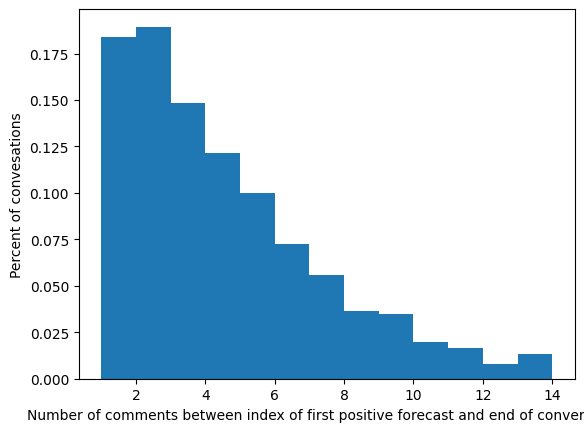

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 3.100439422473321, Median = 2.0
Accuracy                                                         0.710445
Precision                                                        0.671585
Recall                                                           0.823681
FPR                                                              0.402792
F1                                                               0.739898
Mean H                                                           3.100439
Correct Adjustment                                               0.098501
Incorrect Adjustment                                             0.063599
Recovery                                                         0.034902
Leaderboard String      | MODEL_NAME     | 71.0   | 67.2  | 82.4 | 74....
dtype: object
summarization complete.
---
fitting policy DeferralDecisionPolicy for seed 1
starting transformation.


22864it [00:05, 4346.34it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7182, p=0.7063, r=0.7472, fpr=0.3108, f1=0.7261
transformation complete.
corpus dumped.
starting summarization.


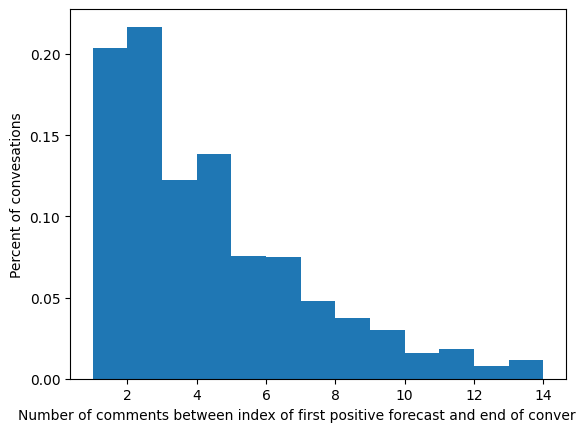

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.8996539792387543, Median = 2.0
Accuracy                                                         0.718201
Precision                                                        0.706256
Recall                                                           0.747156
FPR                                                              0.310755
F1                                                               0.726131
Mean H                                                           2.899654
Correct Adjustment                                               0.077301
Incorrect Adjustment                                             0.069028
Recovery                                                         0.008273
Leaderboard String      | MODEL_NAME     | 71.8   | 70.6  | 74.7 | 72....
dtype: object
summarization complete.
---
[info] summarize only: RandomDeferralDecisionPolicy seed 1


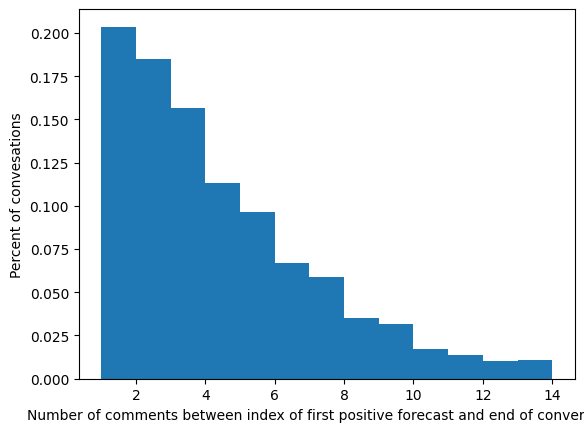

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.984858912594632, Median = 2.0
Accuracy                                                         0.696484
Precision                                                        0.677074
Recall                                                           0.751293
FPR                                                              0.358325
F1                                                               0.712255
Mean H                                                           2.984859
Correct Adjustment                                               0.102637
Incorrect Adjustment                                             0.119442
Recovery                                                        -0.016805
Leaderboard String      | MODEL_NAME     | 69.6   | 67.7  | 75.1 | 71....
dtype: object
---
fitting policy SimulationAverageDecisionPolicy for seed 1
starting transformation.


22864it [00:05, 4338.39it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7014, p=0.6571, r=0.8423, fpr=0.4395, f1=0.7383
transformation complete.
corpus dumped.
starting summarization.


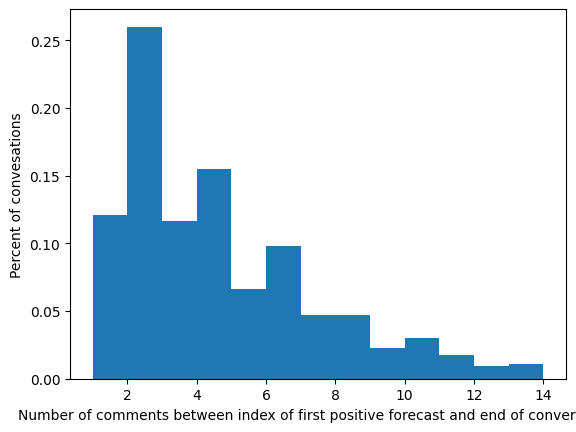

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 3.1964395334561084, Median = 3.0
Accuracy                                                         0.701396
Precision                                                         0.65712
Recall                                                           0.842296
FPR                                                              0.439504
F1                                                               0.738273
Mean H                                                            3.19644
Correct Adjustment                                               0.105739
Incorrect Adjustment                                             0.104188
Recovery                                                         0.001551
Leaderboard String      | MODEL_NAME     | 70.1   | 65.7  | 84.2 | 73....
dtype: object
summarization complete.
---
fitting policy SimulationMajorityDecisionPolicy for seed 1
starting transformation.


22864it [00:05, 4302.22it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.6944, p=0.6519, r=0.8345, fpr=0.4457, f1=0.7320
transformation complete.
corpus dumped.
starting summarization.


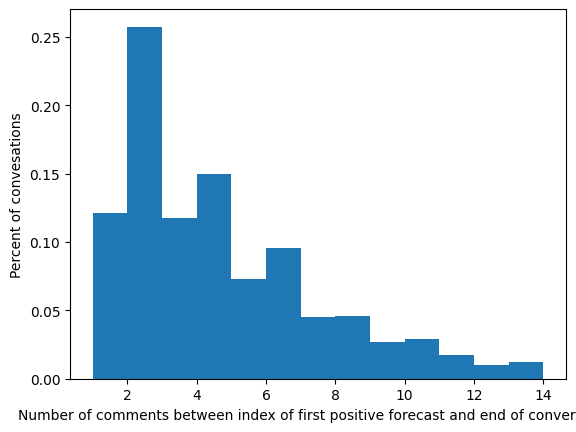

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 3.2280049566294924, Median = 3.0
Accuracy                                                         0.694416
Precision                                                        0.651858
Recall                                                            0.83454
FPR                                                              0.445708
F1                                                               0.731973
Mean H                                                           3.228005
Correct Adjustment                                               0.115564
Incorrect Adjustment                                             0.109876
Recovery                                                         0.005688
Leaderboard String      | MODEL_NAME     | 69.4   | 65.2  | 83.5 | 73....
dtype: object
summarization complete.
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install fl

21768it [00:00, 43078.91it/s]


[info] final transform metrics: processed_contexts=21768, conversations=3668, acc=0.7132, p=0.6875, r=0.7881, fpr=0.3626, f1=0.7343
transformation complete.
corpus dumped.
starting summarization.


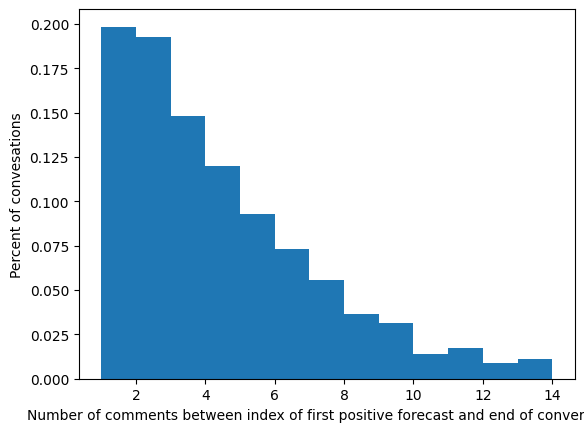

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.9752407152682254, Median = 2.0
Accuracy                                                         0.713195
Precision                                                         0.68747
Recall                                                           0.788076
FPR                                                              0.362589
F1                                                               0.734343
Mean H                                                           2.975241
Correct Adjustment                                               0.091876
Incorrect Adjustment                                             0.067067
Recovery                                                         0.024809
Leaderboard String      | MODEL_NAME     | 71.3   | 68.7  | 78.8 | 73....
dtype: object
summarization complete.
---
fitting policy DeferralDecisionPolicy for seed 2
starting transformation.


21768it [00:05, 4271.72it/s]


[info] final transform metrics: processed_contexts=21768, conversations=3668, acc=0.7156, p=0.7165, r=0.7192, fpr=0.2880, f1=0.7179
transformation complete.
corpus dumped.
starting summarization.


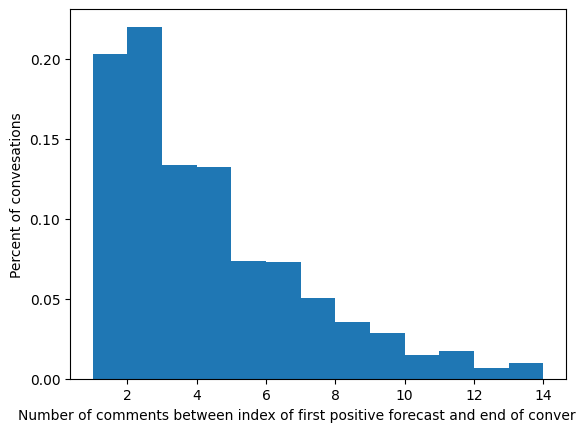

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.841748304446119, Median = 2.0
Accuracy                                                         0.715649
Precision                                                        0.716523
Recall                                                           0.719241
FPR                                                              0.287987
F1                                                               0.717879
Mean H                                                           2.841748
Correct Adjustment                                               0.077426
Incorrect Adjustment                                             0.070883
Recovery                                                         0.006543
Leaderboard String      | MODEL_NAME     | 71.6   | 71.7  | 71.9 | 71....
dtype: object
summarization complete.
---
[info] summarize only: RandomDeferralDecisionPolicy seed 2


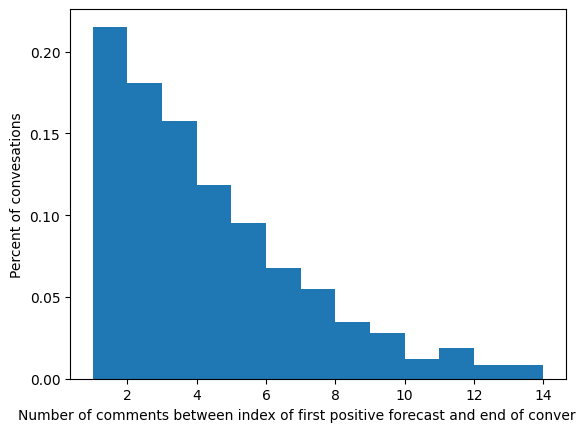

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.8620178041543025, Median = 2.0
Accuracy                                                         0.704471
Precision                                                        0.696641
Recall                                                           0.730623
FPR                                                              0.321997
F1                                                               0.713228
Mean H                                                           2.862018
Correct Adjustment                                               0.093511
Incorrect Adjustment                                             0.121865
Recovery                                                        -0.028353
Leaderboard String      | MODEL_NAME     | 70.4   | 69.7  | 73.1 | 71....
dtype: object
---
fitting policy SimulationAverageDecisionPolicy for seed 2
starting transformation.


21768it [00:05, 4301.26it/s]


[info] final transform metrics: processed_contexts=21768, conversations=3668, acc=0.7056, p=0.6752, r=0.7989, fpr=0.3889, f1=0.7319
transformation complete.
corpus dumped.
starting summarization.


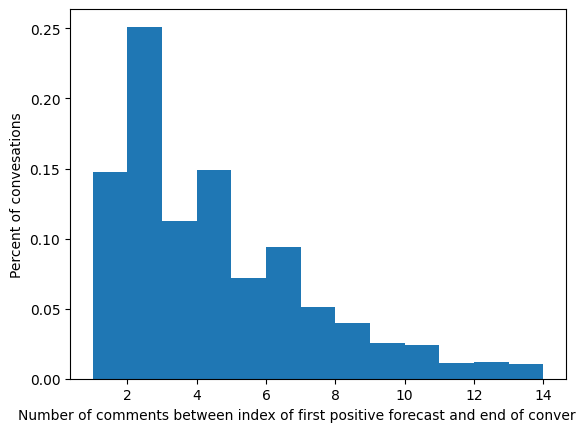

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 3.0698778833107188, Median = 2.0
Accuracy                                                         0.705562
Precision                                                        0.675218
Recall                                                           0.798916
FPR                                                              0.388919
F1                                                               0.731877
Mean H                                                           3.069878
Correct Adjustment                                               0.098691
Incorrect Adjustment                                             0.101418
Recovery                                                        -0.002726
Leaderboard String      | MODEL_NAME     | 70.6   | 67.5  | 79.9 | 73....
dtype: object
summarization complete.
---
fitting policy SimulationMajorityDecisionPolicy for seed 2
starting transformation.


21768it [00:05, 4288.74it/s]


[info] final transform metrics: processed_contexts=21768, conversations=3668, acc=0.7023, p=0.6714, r=0.7995, fpr=0.3961, f1=0.7298
transformation complete.
corpus dumped.
starting summarization.


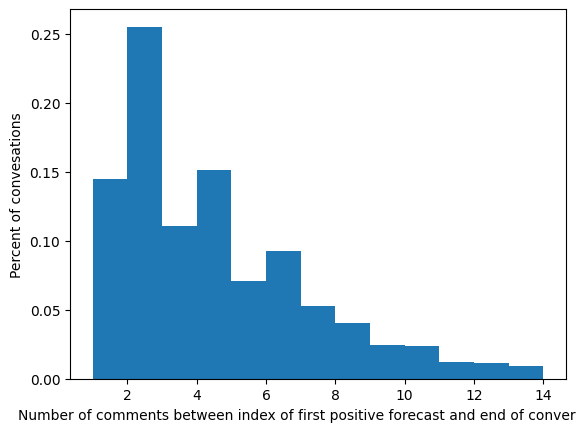

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 3.0691525423728816, Median = 2.0
Accuracy                                                          0.70229
Precision                                                         0.67137
Recall                                                           0.799458
FPR                                                               0.39605
F1                                                               0.729837
Mean H                                                           3.069153
Correct Adjustment                                               0.104689
Incorrect Adjustment                                              0.10578
Recovery                                                        -0.001091
Leaderboard String      | MODEL_NAME     | 70.2   | 67.1  | 79.9 | 73....
dtype: object
summarization complete.
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install fl

22864it [00:00, 46590.36it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7104, p=0.7033, r=0.7280, fpr=0.3071, f1=0.7154
transformation complete.
corpus dumped.
starting summarization.


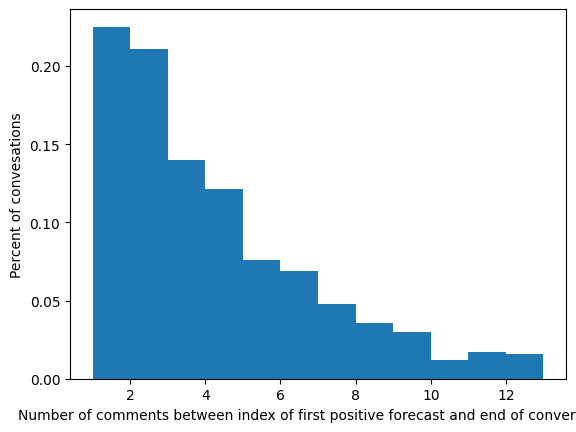

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.7670454545454546, Median = 2.0
Accuracy                                                         0.710445
Precision                                                        0.703297
Recall                                                           0.728025
FPR                                                              0.307135
F1                                                               0.715447
Mean H                                                           2.767045
Correct Adjustment                                               0.075491
Incorrect Adjustment                                             0.065667
Recovery                                                         0.009824
Leaderboard String      | MODEL_NAME     | 71.0   | 70.3  | 72.8 | 71....
dtype: object
summarization complete.
---
fitting policy DeferralDecisionPolicy for seed 3
starting transformation.


22864it [00:05, 4293.18it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7027, p=0.7292, r=0.6448, fpr=0.2394, f1=0.6844
transformation complete.
corpus dumped.
starting summarization.


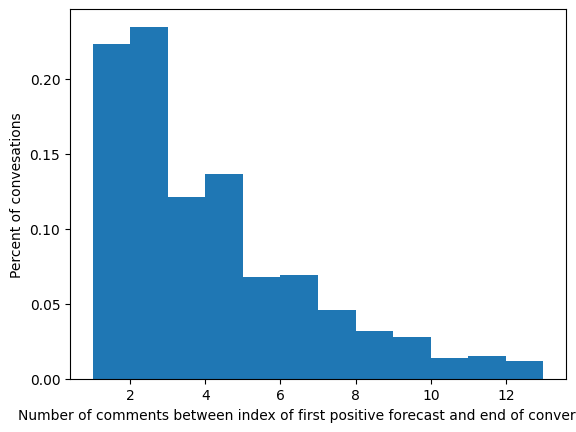

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.6663993584603047, Median = 2.0
Accuracy                                                         0.702689
Precision                                                         0.72924
Recall                                                           0.644778
FPR                                                                0.2394
F1                                                               0.684413
Mean H                                                           2.666399
Correct Adjustment                                               0.063082
Incorrect Adjustment                                             0.066443
Recovery                                                        -0.003361
Leaderboard String      | MODEL_NAME     | 70.3   | 72.9  | 64.5 | 68....
dtype: object
summarization complete.
---
[info] summarize only: RandomDeferralDecisionPolicy seed 3


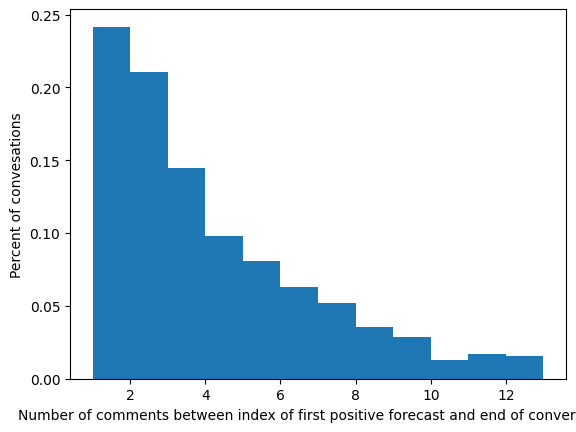

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.716323296354992, Median = 2.0
Accuracy                                                         0.695191
Precision                                                        0.713397
Recall                                                           0.652534
FPR                                                              0.262151
F1                                                                0.68161
Mean H                                                           2.716323
Correct Adjustment                                               0.074199
Incorrect Adjustment                                             0.102637
Recovery                                                        -0.028438
Leaderboard String      | MODEL_NAME     | 69.5   | 71.3  | 65.3 | 68....
dtype: object
---
fitting policy SimulationAverageDecisionPolicy for seed 3
starting transformation.


22864it [00:05, 4320.97it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7006, p=0.6932, r=0.7198, fpr=0.3185, f1=0.7062
transformation complete.
corpus dumped.
starting summarization.


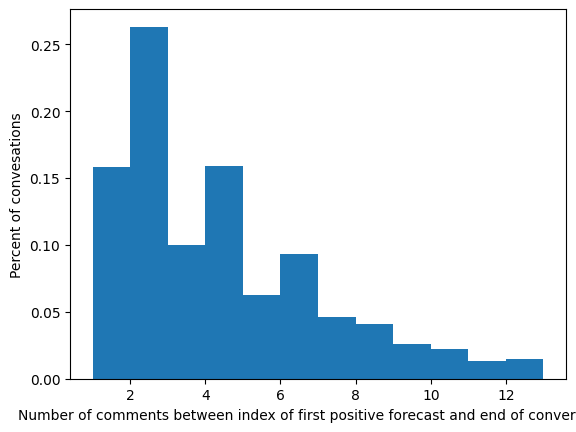

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.9597701149425286, Median = 2.0
Accuracy                                                          0.70062
Precision                                                        0.693227
Recall                                                           0.719752
FPR                                                              0.318511
F1                                                                0.70624
Mean H                                                            2.95977
Correct Adjustment                                                0.08454
Incorrect Adjustment                                             0.103154
Recovery                                                        -0.018614
Leaderboard String      | MODEL_NAME     | 70.1   | 69.3  | 72.0 | 70....
dtype: object
summarization complete.
---
fitting policy SimulationMajorityDecisionPolicy for seed 3
starting transformation.


22864it [00:05, 4280.84it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.6988, p=0.6891, r=0.7244, fpr=0.3268, f1=0.7063
transformation complete.
corpus dumped.
starting summarization.


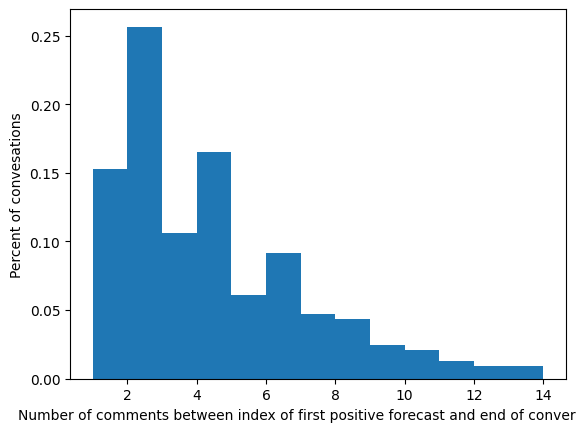

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.9864382583868667, Median = 2.0
Accuracy                                                         0.698811
Precision                                                        0.689129
Recall                                                           0.724405
FPR                                                              0.326784
F1                                                               0.706327
Mean H                                                           2.986438
Correct Adjustment                                               0.087642
Incorrect Adjustment                                             0.108066
Recovery                                                        -0.020424
Leaderboard String      | MODEL_NAME     | 69.9   | 68.9  | 72.4 | 70....
dtype: object
summarization complete.
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install fl

22864it [00:00, 46478.45it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7045, p=0.6930, r=0.7342, fpr=0.3252, f1=0.7130
transformation complete.
corpus dumped.
starting summarization.


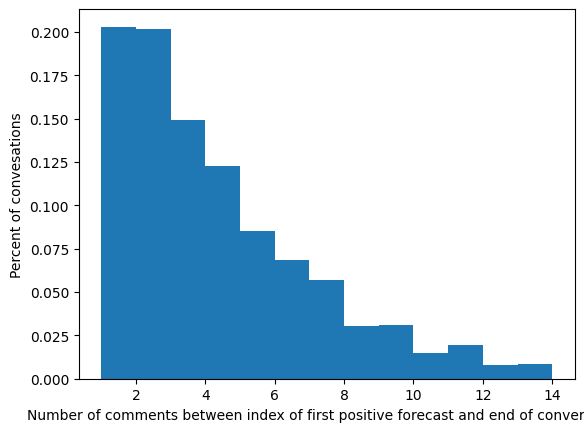

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.8922535211267606, Median = 2.0
Accuracy                                                         0.704498
Precision                                                        0.693021
Recall                                                            0.73423
FPR                                                              0.325233
F1                                                                0.71303
Mean H                                                           2.892254
Correct Adjustment                                               0.083247
Incorrect Adjustment                                             0.071355
Recovery                                                         0.011892
Leaderboard String      | MODEL_NAME     | 70.4   | 69.3  | 73.4 | 71....
dtype: object
summarization complete.
---
fitting policy DeferralDecisionPolicy for seed 4
starting transformation.


22864it [00:05, 4268.73it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7035, p=0.7250, r=0.6556, fpr=0.2487, f1=0.6886
transformation complete.
corpus dumped.
starting summarization.


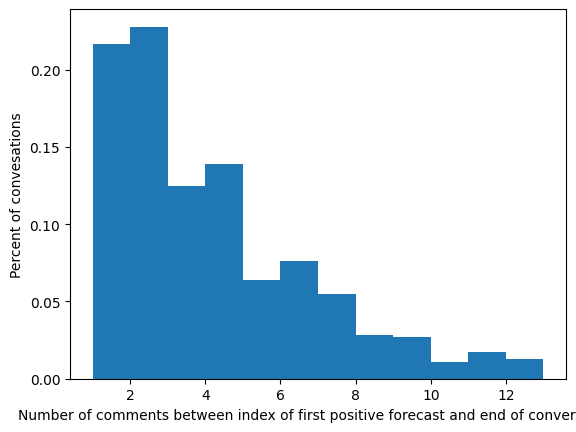

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.723186119873817, Median = 2.0
Accuracy                                                         0.703464
Precision                                                        0.724986
Recall                                                           0.655636
FPR                                                              0.248707
F1                                                               0.688569
Mean H                                                           2.723186
Correct Adjustment                                                0.06515
Incorrect Adjustment                                             0.073681
Recovery                                                        -0.008532
Leaderboard String      | MODEL_NAME     | 70.3   | 72.5  | 65.6 | 68....
dtype: object
summarization complete.
---
[info] summarize only: RandomDeferralDecisionPolicy seed 4


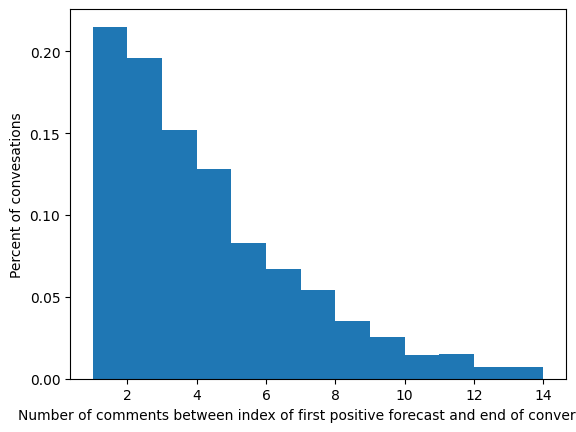

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.78343949044586, Median = 2.0
Accuracy                                                         0.683299
Precision                                                        0.696617
Recall                                                           0.649431
FPR                                                              0.282834
F1                                                               0.672197
Mean H                                                           2.783439
Correct Adjustment                                               0.081437
Incorrect Adjustment                                             0.109617
Recovery                                                         -0.02818
Leaderboard String      | MODEL_NAME     | 68.3   | 69.7  | 64.9 | 67....
dtype: object
---
fitting policy SimulationAverageDecisionPolicy for seed 4
starting transformation.


22864it [00:05, 4302.66it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.6988, p=0.6855, r=0.7347, fpr=0.3371, f1=0.7093
transformation complete.
corpus dumped.
starting summarization.


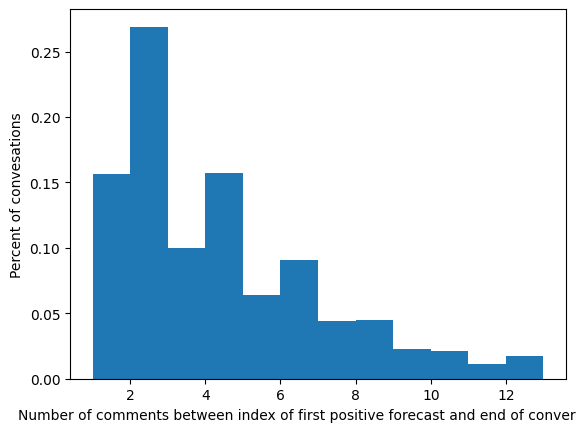

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.9500351864883885, Median = 2.0
Accuracy                                                         0.698811
Precision                                                         0.68548
Recall                                                           0.734747
FPR                                                              0.337125
F1                                                               0.709259
Mean H                                                           2.950035
Correct Adjustment                                               0.088676
Incorrect Adjustment                                              0.10393
Recovery                                                        -0.015253
Leaderboard String      | MODEL_NAME     | 69.9   | 68.5  | 73.5 | 70....
dtype: object
summarization complete.
---
fitting policy SimulationMajorityDecisionPolicy for seed 4
starting transformation.


22864it [00:05, 4286.36it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7006, p=0.6839, r=0.7461, fpr=0.3449, f1=0.7136
transformation complete.
corpus dumped.
starting summarization.


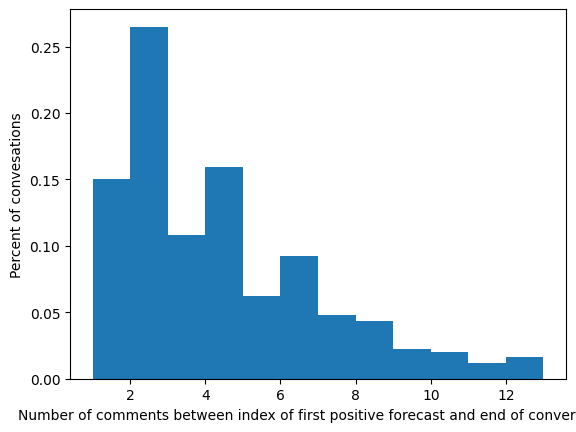

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.963270963270963, Median = 2.0
Accuracy                                                          0.70062
Precision                                                        0.683886
Recall                                                           0.746122
FPR                                                              0.344881
F1                                                                0.71365
Mean H                                                           2.963271
Correct Adjustment                                               0.089969
Incorrect Adjustment                                             0.111427
Recovery                                                        -0.021458
Leaderboard String      | MODEL_NAME     | 70.1   | 68.4  | 74.6 | 71....
dtype: object
summarization complete.
Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install fla

22864it [00:00, 46248.29it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7063, p=0.6973, r=0.7291, fpr=0.3164, f1=0.7128
transformation complete.
corpus dumped.
starting summarization.


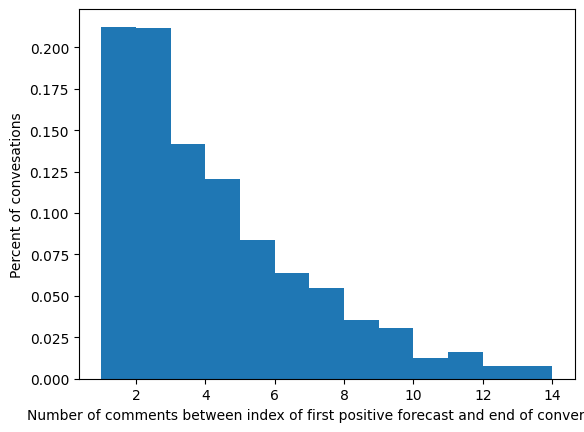

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.819858156028369, Median = 2.0
Accuracy                                                         0.706308
Precision                                                        0.697329
Recall                                                           0.729059
FPR                                                              0.316443
F1                                                               0.712841
Mean H                                                           2.819858
Correct Adjustment                                                0.08273
Incorrect Adjustment                                             0.067735
Recovery                                                         0.014995
Leaderboard String      | MODEL_NAME     | 70.6   | 69.7  | 72.9 | 71....
dtype: object
summarization complete.
---
fitting policy DeferralDecisionPolicy for seed 5
starting transformation.


22864it [00:05, 4299.92it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7027, p=0.7253, r=0.6525, fpr=0.2472, f1=0.6870
transformation complete.
corpus dumped.
starting summarization.


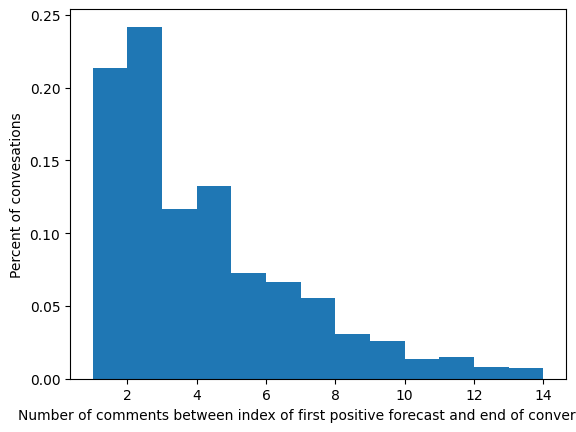

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.713153724247227, Median = 2.0
Accuracy                                                         0.702689
Precision                                                        0.725287
Recall                                                           0.652534
FPR                                                              0.247156
F1                                                                0.68699
Mean H                                                           2.713154
Correct Adjustment                                               0.067994
Incorrect Adjustment                                             0.074974
Recovery                                                         -0.00698
Leaderboard String      | MODEL_NAME     | 70.3   | 72.5  | 65.3 | 68....
dtype: object
summarization complete.
---
[info] summarize only: RandomDeferralDecisionPolicy seed 5


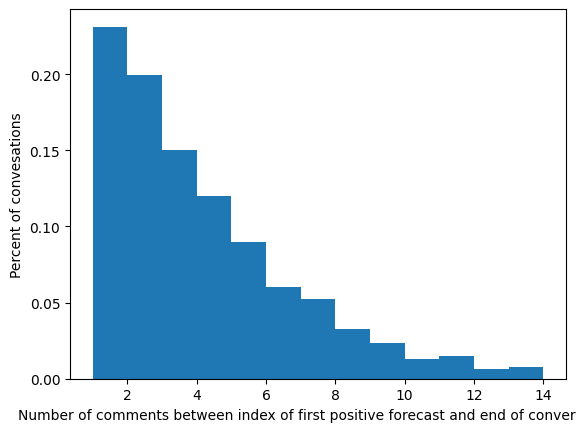

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.6946386946386944, Median = 2.0
Accuracy                                                         0.690021
Precision                                                        0.699837
Recall                                                            0.66546
FPR                                                              0.285419
F1                                                               0.682216
Mean H                                                           2.694639
Correct Adjustment                                               0.085315
Incorrect Adjustment                                             0.109359
Recovery                                                        -0.024043
Leaderboard String      | MODEL_NAME     | 69.0   | 70.0  | 66.5 | 68....
dtype: object
---
fitting policy SimulationAverageDecisionPolicy for seed 5
starting transformation.


22864it [00:05, 4304.83it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.7042, p=0.6934, r=0.7322, fpr=0.3237, f1=0.7123
transformation complete.
corpus dumped.
starting summarization.


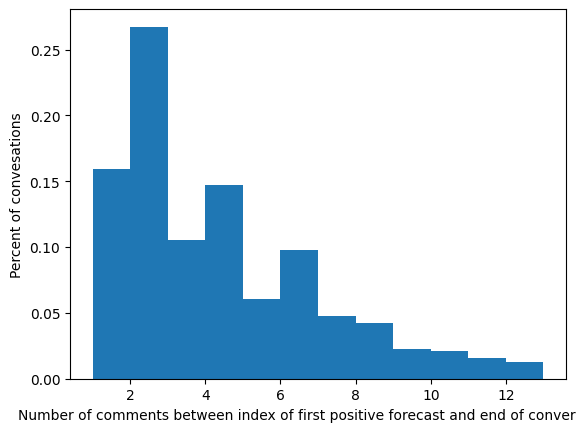

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.9491525423728815, Median = 2.0
Accuracy                                                          0.70424
Precision                                                        0.693438
Recall                                                           0.732161
FPR                                                              0.323681
F1                                                               0.712274
Mean H                                                           2.949153
Correct Adjustment                                               0.088159
Incorrect Adjustment                                             0.111427
Recovery                                                        -0.023268
Leaderboard String      | MODEL_NAME     | 70.4   | 69.3  | 73.2 | 71....
dtype: object
summarization complete.
---
fitting policy SimulationMajorityDecisionPolicy for seed 5
starting transformation.


22864it [00:05, 4225.02it/s]


[info] final transform metrics: processed_contexts=22864, conversations=3868, acc=0.6996, p=0.6883, r=0.7296, fpr=0.3304, f1=0.7083
transformation complete.
corpus dumped.
starting summarization.


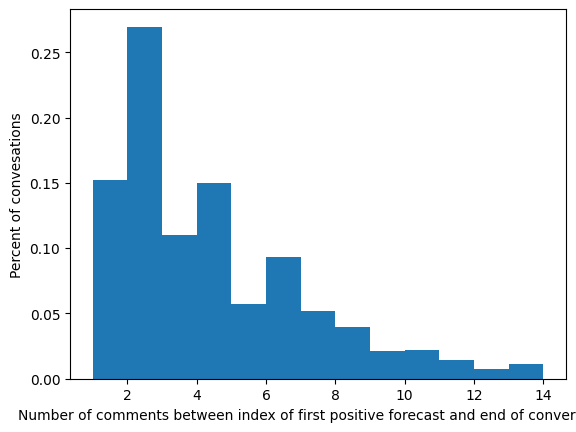

Horizon statistics (# of comments between first positive forecast and conversation end):
Mean = 2.966690290574061, Median = 2.0
Accuracy                                                         0.699586
Precision                                                        0.688293
Recall                                                           0.729576
FPR                                                              0.330403
F1                                                               0.708333
Mean H                                                            2.96669
Correct Adjustment                                               0.090486
Incorrect Adjustment                                             0.112203
Recovery                                                        -0.021717
Leaderboard String      | MODEL_NAME     | 70.0   | 68.8  | 73.0 | 70....
dtype: object
summarization complete.


In [ ]:
for seed_idx in SEEDS:
    config = TransformerForecasterConfig(
        output_dir=f"outputs/{OUTPUT_DIR}/forecaster_{seed_idx}",
        per_device_batch_size=16,
        gradient_accumulation_steps=1,
        num_train_epochs=1,
        learning_rate=1e-5,
        random_seed=seed_idx,
        context_mode="normal",
        device="cuda",
    )

    forecaster_model = TransformerDecoderModel(
        model_name_or_path="google/gemma-2-9b-it",
        config=config,
    )

    forecaster = Forecaster(
        forecaster_model=forecaster_model,
        labeler='has_removed_comment',
    )

    # remove training---we can instead use the cached forecast probabilities.

    # ---
    cfg_path = os.path.join(repo_root, "saves", f"seed-{seed_idx}", "dev_config.json")
    if seed_idx == 1:
        best_threshold = 0.5926666259765625
    elif seed_idx == 2:
        best_threshold = 0.622459352016449
    elif seed_idx == 3:
        best_threshold = 0.6513549089431763
    elif seed_idx == 4:
        best_threshold = 0.6513549089431763
    elif seed_idx == 5:
        best_threshold = 0.6513549089431763
    
    for policy_trial in [ThresholdDecisionPolicy, DeferralDecisionPolicy, RandomDeferralDecisionPolicy, SimulationAverageDecisionPolicy, SimulationMajorityDecisionPolicy]:
        corpus_name = f"seed-{seed_idx}-{policy_trial.__name__}"
        if corpus_name in corpora_all:
            corpus = corpora_all[corpus_name]
        else:
            raise KeyError(f"missing corpus {corpus_name}")

        if policy_trial == RandomDeferralDecisionPolicy:
            # bundled corpus already has forecast/forecast_prob; re-transform would redraw np.random.
            print('---')
            print(f"[info] summarize only: {policy_trial.__name__} seed {seed_idx}")
            def summarize_selector(convo):
                return convo.meta.get("split") == "test"
            conversational_forecasts_df, metrics = forecaster.summarize(
                corpus=corpus,
                selector=summarize_selector,
            )
            seed_folder = f"outputs/{OUTPUT_DIR}/seed-{seed_idx}-{policy_trial.__name__}"
            os.makedirs(seed_folder, exist_ok=True)
            conversational_forecasts_df.to_csv(
                os.path.join(seed_folder, "conversational_forecasts.csv"), index=False
            )
            with open(os.path.join(seed_folder, "metrics.json"), "w") as f:
                json.dump(metrics, f, indent=2)
            continue

        print('---')
        print(f"fitting policy {policy_trial.__name__} for seed {seed_idx}")
        if policy_trial == ThresholdDecisionPolicy:
            policy = ThresholdDecisionPolicy(
                threshold=best_threshold,
            )
        elif policy_trial == DeferralDecisionPolicy:
            policy = DeferralDecisionPolicy(
                simulator=simulator_model,
                threshold=best_threshold,
                tau=TAU,
            )
        elif policy_trial == SimulationAverageDecisionPolicy:
            policy = SimulationAverageDecisionPolicy(
                simulator=simulator_model,
                threshold=best_threshold,
                num_simulations=NUM_SIMULATIONS,
                store_simulations=False,
                simulated_reply_attribute_name="sim_replies",
                sim_replies_forecast_probs_attribute_name="sim_replies_forecast_probs",
            )
        elif policy_trial == SimulationMajorityDecisionPolicy:
            policy = SimulationMajorityDecisionPolicy(
                simulator=simulator_model,
                threshold=best_threshold,
                tau=5,
                num_simulations=NUM_SIMULATIONS,
                store_simulations=False,
                simulated_reply_attribute_name="sim_replies",
                sim_replies_forecast_probs_attribute_name="sim_replies_forecast_probs",
            )
        
        # attach the decision policy to the underlying forecaster model;
        # Forecaster itself does not accept decision_policy in its constructor.
        forecaster_model.decision_policy = policy

        forecaster = Forecaster(
            forecaster_model=forecaster_model,
            labeler='has_removed_comment',
        )

        print('starting transformation.')
        # evaluate the forecaster on the test set
        forecaster.transform(
            corpus=corpus,
            context_selector=make_data_selector('test'),
            verbose=False,
        )
        print('transformation complete.')

        output_dir = f"outputs/{OUTPUT_DIR}/seed-{seed_idx}-{policy_trial.__name__}"
        os.makedirs(output_dir, exist_ok=True)
        corpus.dump(name=f"{policy_trial.__name__}", base_path=output_dir)
        print('corpus dumped.')

        print('starting summarization.')
        # forecaster.summarize expects a conversation-level selector (Callable[[Conversation], bool]),
        # unlike the context-tuple selectors used in fit/transform.
        def summarize_selector(convo):
            return convo.meta.get("split") == "test"
        conversational_forecasts_df, metrics = forecaster.summarize(
            corpus=corpus,
            selector=summarize_selector,
        )
        print('summarization complete.')
        
        # path to the seed output directory
        seed_folder = f"outputs/{OUTPUT_DIR}/seed-{seed_idx}-{policy_trial.__name__}"

        # ensure the directory exists
        os.makedirs(seed_folder, exist_ok=True)

        # save conversational_forecasts_df as CSV
        conversational_forecasts_df.to_csv(os.path.join(seed_folder, "conversational_forecasts.csv"), index=False)

        # save metrics as JSON
        with open(os.path.join(seed_folder, "metrics.json"), "w") as f:
            json.dump(metrics, f, indent=2)
            

Below is a script to retrain forecasters and regenerating simulations.

In [ ]:
for seed_idx in SEEDS:
    train_corpus = Corpus(filename=download('conversations-gone-awry-cmv-corpus-large'))
    # corpus = Corpus(filename=f'/reef/lyk25/theres-a-way-out-ACL26-internal/outputs/benchmark_preannotated/seed-{seed_idx}-ThresholdDecisionPolicy/ThresholdDecisionPolicy')
    # corpus = Corpus(filename=f'/reef/lyk25/dynamic_training/game_analysis/corpi/test/test-son-seed-{seed_idx}')
    corpus = Corpus(filename=download('conversations-gone-awry-cmv-corpus-large'))
    corpus.filter_conversations_by(lambda convo: convo.meta['split'] == 'test')

    config = TransformerForecasterConfig(
        output_dir=f"outputs/{OUTPUT_DIR}/forecaster_{seed_idx}",
        per_device_batch_size=16,
        gradient_accumulation_steps=1,
        num_train_epochs=1,
        learning_rate=1e-5,
        random_seed=seed_idx,
        context_mode="normal",
        device="cuda",
    )

    forecaster_model = TransformerDecoderModel(
        model_name_or_path="google/gemma-2-9b-it",
        config=config,
    )

    forecaster = Forecaster(
        forecaster_model=forecaster_model,
        labeler='has_removed_comment',
    )

    forecaster.fit_belief_estimator(
        corpus=train_corpus,
        context_selector=train_context_selector,
        val_context_selector=val_context_selector,
    )

    # ---
    cfg_path = os.path.join(repo_root, "saves", f"seed-{seed_idx}", "dev_config.json")
    with open(cfg_path) as f:
        cfg = json.load(f)
    best_threshold = cfg['best_threshold']

    for policy_trial in [ThresholdDecisionPolicy, DeferralDecisionPolicy, RandomDeferralDecisionPolicy, SimulationAverageDecisionPolicy, SimulationMajorityDecisionPolicy]:
        print('---')
        print(f"Fitting policy {policy_trial.__name__} for seed {seed_idx}")
        if policy_trial == ThresholdDecisionPolicy:
            policy = ThresholdDecisionPolicy(
                threshold=best_threshold,
                reuse_cached_forecast_probs=False,
            )
        elif policy_trial == DeferralDecisionPolicy:
            policy = DeferralDecisionPolicy(
                simulator=simulator_model,
                threshold=best_threshold,
                tau=TAU,
                reuse_cached_forecast_probs=False,
            )
        elif policy_trial == RandomDeferralDecisionPolicy:
            policy = RandomDeferralDecisionPolicy(
                simulator=simulator_model,
                threshold=best_threshold,
                deferral_probability=DEFERRAL_PROBABILITY_THRESHOLD,
                reuse_cached_forecast_probs=False,
            )
        elif policy_trial == SimulationAverageDecisionPolicy:
            policy = SimulationAverageDecisionPolicy(
                simulator=simulator_model,
                threshold=best_threshold,
                num_simulations=NUM_SIMULATIONS,
                store_simulations=False,
                simulated_reply_attribute_name="sim_replies",
                sim_replies_forecast_probs_attribute_name="sim_replies_forecast_probs",
                reuse_cached_forecast_probs=False,
            )
        elif policy_trial == SimulationMajorityDecisionPolicy:
            policy = SimulationMajorityDecisionPolicy(
                simulator=simulator_model,
                threshold=best_threshold,
                tau=5,
                num_simulations=NUM_SIMULATIONS,
                store_simulations=False,
                simulated_reply_attribute_name="sim_replies",
                sim_replies_forecast_probs_attribute_name="sim_replies_forecast_probs",
                reuse_cached_forecast_probs=False,
            )
        
        # attach the decision policy to the underlying forecaster model;
        # Forecaster itself does not accept decision_policy in its constructor.
        forecaster_model.decision_policy = policy

        forecaster = Forecaster(
            forecaster_model=forecaster_model,
            labeler='has_removed_comment',
        )

        print('starting transformation.')
        # evaluate the forecaster on the test set
        forecaster.transform(
            corpus=corpus,
            context_selector=make_data_selector('test'),
            verbose=True,
        )
        print('transformation complete.')

        output_dir = f"outputs/{OUTPUT_DIR}/seed-{seed_idx}-{policy_trial.__name__}"
        os.makedirs(output_dir, exist_ok=True)
        corpus.dump(name=f"{policy_trial.__name__}", base_path=output_dir)
        print('corpus dumped.')

        print('starting summarization.')
        # forecaster.summarize expects a conversation-level selector (Callable[[Conversation], bool]),
        # unlike the context-tuple selectors used in fit/transform.
        def summarize_selector(convo):
            return convo.meta.get("split") == "test"
        conversational_forecasts_df, metrics = forecaster.summarize(
            corpus=corpus,
            selector=summarize_selector,
        )
        print('summarization complete.')
        
        # path to the seed output directory
        seed_folder = f"outputs/{OUTPUT_DIR}/seed-{seed_idx}-{policy_trial.__name__}"

        # ensure the directory exists
        os.makedirs(seed_folder, exist_ok=True)

        # save conversational_forecasts_df as CSV
        conversational_forecasts_df.to_csv(os.path.join(seed_folder, "conversational_forecasts.csv"), index=False)

        # save metrics as JSON
        with open(os.path.join(seed_folder, "metrics.json"), "w") as f:
            json.dump(metrics, f, indent=2)

To view our results:

In [18]:
import os
import json
from collections import defaultdict

def fmt_mean(values):
    # sample std dev requires n>=2; show 0 std for single-seed runs so output stays readable.
    mean_val = sum(values) / len(values)
    return f"{mean_val:.4f}"

benchmark_dir = "outputs/" + OUTPUT_DIR

SEEDS = list(range(1, 6))
POLICIES = [
    "ThresholdDecisionPolicy",
    "DeferralDecisionPolicy",
    "RandomDeferralDecisionPolicy",
    "SimulationAverageDecisionPolicy",
    "SimulationMajorityDecisionPolicy",
]


def _resolve_metrics_path(benchmark_dir, seed_idx, policy):
    # summarize-only reads frozen bundle corpora; full runs write seed-<n>-<policy>/ after transform.
    # check summarize_only first: for RandomDeferral, a stale seed-<n>/ from an old transform can
    # disagree with the bundled corpus, and mixing primary for some seeds with summarize_only for
    # others skews per-policy means.
    summarize = os.path.join(
        benchmark_dir, f"summarize_only-seed-{seed_idx}-{policy}", "metrics.json"
    )
    full_run = os.path.join(benchmark_dir, f"seed-{seed_idx}-{policy}", "metrics.json")
    if os.path.exists(summarize):
        return summarize
    if os.path.exists(full_run):
        return full_run
    return None


# metrics_by_policy[policy][metric_name] -> list of per-seed values
metrics_by_policy = defaultdict(lambda: defaultdict(list))
seeds_found_by_policy = defaultdict(list)

for policy in POLICIES:
    for seed_idx in SEEDS:
        metrics_path = _resolve_metrics_path(benchmark_dir, seed_idx, policy)
        if metrics_path is None:
            print(
                f"warn: missing metrics for seed {seed_idx} {policy} "
                f"(looked for summarize_only-seed-{seed_idx}-{policy}/ and seed-{seed_idx}-{policy}/), skipping"
            )
            continue
        with open(metrics_path) as f:
            m = json.load(f)
        seeds_found_by_policy[policy].append(seed_idx)
        for k, v in m.items():
            # only average numeric metrics; skip strings like "leaderboard string"
            if isinstance(v, (int, float)):
                metrics_by_policy[policy][k].append(v)

# print means per policy
for policy in POLICIES:
    seeds_found = seeds_found_by_policy.get(policy, [])
    if not seeds_found:
        print(f"\n{policy}: no seeds found")
        continue
    print(f"\n{policy} (seeds={seeds_found}, n={len(seeds_found)})")
    for metric_name, values in metrics_by_policy[policy].items():
        print(f"  {metric_name}: {fmt_mean(values)}")



ThresholdDecisionPolicy (seeds=[1, 2, 3, 4, 5], n=5)
  Accuracy: 0.7090
  Precision: 0.6905
  Recall: 0.7606
  FPR: 0.3428
  F1: 0.7231
  Mean H: 2.9110
  Correct Adjustment: 0.0864
  Incorrect Adjustment: 0.0671
  Recovery: 0.0193

DeferralDecisionPolicy (seeds=[1, 2, 3, 4, 5], n=5)
  Accuracy: 0.7085
  Precision: 0.7205
  Recall: 0.6839
  FPR: 0.2668
  F1: 0.7008
  Mean H: 2.7688
  Correct Adjustment: 0.0702
  Incorrect Adjustment: 0.0710
  Recovery: -0.0008

RandomDeferralDecisionPolicy (seeds=[1, 2, 3, 4, 5], n=5)
  Accuracy: 0.6939
  Precision: 0.6967
  Recall: 0.6899
  FPR: 0.3021
  F1: 0.6923
  Mean H: 2.8083
  Correct Adjustment: 0.0874
  Incorrect Adjustment: 0.1126
  Recovery: -0.0252

SimulationAverageDecisionPolicy (seeds=[1, 2, 3, 4, 5], n=5)
  Accuracy: 0.7021
  Precision: 0.6809
  Recall: 0.7656
  FPR: 0.3615
  F1: 0.7196
  Mean H: 3.0251
  Correct Adjustment: 0.0932
  Incorrect Adjustment: 0.1048
  Recovery: -0.0117

SimulationMajorityDecisionPolicy (seeds=[1, 2, 3, 4,

## 4. Human benchmark analysis

In [ ]:
corpus = Corpus(filename=download("human-benchmark"))

[info] reading download config from /reef/lyk25/ConvoKit/download_config.json
[info] downloading human-benchmark from https://zissou.infosci.cornell.edu/convokit/datasets/human-benchmark/human-benchmark.zip
[info] extracting /home/lyk25/.convokit/saved-corpora/human-benchmark.zip to /home/lyk25/.convokit/saved-corpora


In [8]:
from collections import defaultdict
import numpy as np

def _truth(convo):
    return bool(convo.meta.get("has_removed_comment", False))

def _round_seen(convo, round_label):
    seen_by_round = convo.meta.get("human_seen_by_round", {})
    return list(seen_by_round.get(round_label, []))

def _round_guesses(utt, round_label):
    guesses_by_round = utt.meta.get("human_guesses_by_round", {})
    return list(guesses_by_round.get(round_label, []))

def _compute_metrics(tp, fp, tn, fn):
    total = tp + fp + tn + fn
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    return {
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "accuracy": accuracy, "precision": precision, "recall": recall,
        "f1": f1, "fpr": fpr, "specificity": specificity, "fnr": fnr,
    }

def _horizon_mean(horizons):
    if len(horizons) == 0:
        return float("nan"), 0
    return float(np.mean(horizons)) - 1, len(horizons)

def _human_per_player_preds(corpus, round_label):
    preds = defaultdict(dict)

    for convo in corpus.iter_conversations():
        seen_players = _round_seen(convo, round_label)
        if not seen_players:
            continue

        utts = convo.get_chronological_utterance_list()
        guessed_players = {
            player
            for utt in utts
            for player in _round_guesses(utt, round_label)
        }

        for player in seen_players:
            preds[player][convo.id] = int(player in guessed_players)

    return preds

def _human_horizons(corpus, round_label):
    by_player = defaultdict(list)

    for convo in corpus.iter_conversations():
        if not _truth(convo):
            continue

        utts = convo.get_chronological_utterance_list()
        seen_players = set()

        for i, utt in enumerate(utts):
            for player in _round_guesses(utt, round_label):
                if player in seen_players:
                    continue
                by_player[player].append(len(utts) - i)
                seen_players.add(player)

    return by_player

def _per_player_metrics(corpus, preds):
    rows = {}

    for player, convo_preds in preds.items():
        tp = fp = tn = fn = 0

        for cid, pred in convo_preds.items():
            convo = corpus.get_conversation(cid)
            truth = int(_truth(convo))

            if pred and truth:
                tp += 1
            elif pred and not truth:
                fp += 1
            elif not pred and not truth:
                tn += 1
            else:
                fn += 1

        rows[player] = _compute_metrics(tp, fp, tn, fn)

    return rows

def _mean_over_players(per_player):
    keys = ["accuracy", "precision", "recall", "f1", "fpr", "specificity", "fnr"]
    if not per_player:
        return {k: float("nan") for k in keys}
    return {k: float(np.mean([m[k] for m in per_player.values()])) for k in keys}

def _gemma_metrics(corpus):
    gemma_per_seed = []

    for seed_num in range(1, 6):
        tp = fp = tn = fn = 0

        for convo in corpus.iter_conversations():
            utts = convo.get_chronological_utterance_list()
            pred = any(
                utt.meta.get("model_forecasts", {}).get(f"seed_{seed_num}") == 1
                for utt in utts
            )
            truth = _truth(convo)

            if pred and truth:
                tp += 1
            elif pred and not truth:
                fp += 1
            elif not pred and not truth:
                tn += 1
            else:
                fn += 1

        gemma_per_seed.append(_compute_metrics(tp, fp, tn, fn))

    gemma_mean = {k: float(np.mean([m[k] for m in gemma_per_seed])) for k in gemma_per_seed[0]}
    gemma_std = {k: float(np.std([m[k] for m in gemma_per_seed], ddof=1)) for k in gemma_per_seed[0]}
    return gemma_mean, gemma_std

def _print_horizons(label, by_player):
    print(f"human horizon ({label}, tps only, mean - 1):")

    player_h = []
    for player in sorted(by_player):
        h, n = _horizon_mean(by_player[player])
        player_h.append(h)
        print(f"  player {player}: n={n}, h={h:.4f}")

    all_vals = [v for vs in by_player.values() for v in vs]
    mean_over_players = float(np.mean(player_h)) if player_h else float("nan")
    pooled_h, pooled_n = _horizon_mean(all_vals)

    print(f"  mean over players: h={mean_over_players:.4f}")
    print(f"  pooled: n={pooled_n}, h={pooled_h:.4f}")
    return mean_over_players, pooled_h

metric_order = ["accuracy", "precision", "recall", "f1", "fpr", "specificity", "fnr"]

def _print_per_player(label, per_player):
    print(f"{label} - per-player metrics:")
    header = f"  {'player':<10}" + "".join(f"{m:>12}" for m in metric_order) + f"{'n_convos':>10}"
    print(header)

    for player in sorted(per_player):
        m = per_player[player]
        n = m["tp"] + m["fp"] + m["tn"] + m["fn"]
        row = f"  {player:<10}" + "".join(f"{m[k]:>12.4f}" for k in metric_order) + f"{n:>10d}"
        print(row)

round1_h = _human_horizons(corpus, "round_1")
round2_h = _human_horizons(corpus, "round_2")
r1_mean, r1_pooled = _print_horizons("round 1", round1_h)
r2_mean, r2_pooled = _print_horizons("round 2", round2_h)

round1_preds = _human_per_player_preds(corpus, "round_1")
round2_preds = _human_per_player_preds(corpus, "round_2")

round1_per_player = _per_player_metrics(corpus, round1_preds)
round2_per_player = _per_player_metrics(corpus, round2_preds)

round1_mean_over_players = _mean_over_players(round1_per_player)
round2_mean_over_players = _mean_over_players(round2_per_player)

gemma_mean, gemma_std = _gemma_metrics(corpus)

print()
_print_per_player("round 1", round1_per_player)
print()
_print_per_player("round 2", round2_per_player)

print()
print("aggregate benchmark (gemma: mean+/-std over 5 seeds; humans: mean over players)")
header = f"{'group':<36}" + "".join(f"{m:>14}" for m in metric_order)
print(header)

def _fmt_mean_std(mean_dict, std_dict):
    return "".join(f"{mean_dict[k]:>7.3f}+/-{std_dict[k]:<5.3f}" for k in metric_order)

def _fmt_mean(mean_dict):
    return "".join(f"{mean_dict[k]:>14.4f}" for k in metric_order)

print(f"{'gemma (mean+/-std over seeds)':<36}" + _fmt_mean_std(gemma_mean, gemma_std))
print(f"{'round1 humans (mean over players)':<36}" + _fmt_mean(round1_mean_over_players))
print(f"{'round2 humans (mean over players)':<36}" + _fmt_mean(round2_mean_over_players))

round1_unique_convos = {cid for preds in round1_preds.values() for cid in preds}
round2_unique_convos = {cid for preds in round2_preds.values() for cid in preds}

print()
print(f"round 1 unique convos: {len(round1_unique_convos)}")
print(f"round 2 unique convos: {len(round2_unique_convos)}")

human horizon (round 1, tps only, mean - 1):
  player 1: n=2, h=1.5000
  player 2: n=1, h=2.0000
  player 3: n=2, h=2.5000
  player 4: n=4, h=1.5000
  player 5: n=4, h=2.5000
  player 6: n=2, h=0.5000
  player 7: n=4, h=2.2500
  player 8: n=2, h=5.0000
  player 9: n=1, h=6.0000
  mean over players: h=2.6389
  pooled: n=22, h=2.3636
human horizon (round 2, tps only, mean - 1):
  player 1: n=4, h=3.2500
  player 2: n=2, h=0.5000
  player 3: n=1, h=3.0000
  player 4: n=2, h=0.5000
  player 5: n=4, h=3.0000
  player 6: n=2, h=4.0000
  player 7: n=4, h=1.2500
  player 8: n=3, h=2.0000
  player 9: n=3, h=1.6667
  mean over players: h=2.1296
  pooled: n=25, h=2.1600

round 1 - per-player metrics:
  player        accuracy   precision      recall          f1         fpr specificity         fnr  n_convos
  1               0.6000      0.6667      0.4000      0.5000      0.2000      0.8000      0.6000        10
  2               0.4000      0.3333      0.2000      0.2500      0.4000      0.6000   

## 5. Validation of forecast probability decrease

In [10]:
seed_best_thresholds = {
    "test-seed-1": 0.5926666259765625,
    "test-seed-2": 0.622459352016449,
    "test-seed-3": 0.6513549089431763,
    "test-seed-4": 0.6513549089431763,
    "test-seed-5": 0.6513549089431763,
}

In [11]:
import json
from pathlib import Path
from convokit import Corpus

corpus_base = Path("/reef/lyk25/dynamic_training/game_analysis/corpi/test")
# config_base = Path("")
# replace here with your own base path with multiple seeds

corpus_dirs = sorted(
    corpus_dir
    for corpus_dir in corpus_base.rglob("*")
    if corpus_dir.is_dir() and (corpus_dir / "index.json").exists()
)

if not corpus_dirs:
    raise FileNotFoundError(f"no convokit corpora found under {corpus_base}")


def _test_seed_key(corpus_dir):
    parent_name = corpus_dir.parent.name
    if parent_name.startswith("test-seed-"):
        return parent_name
    seed_idx = corpus_dir.name.rsplit("-", 1)[-1]
    return f"test-seed-{seed_idx}"


corpus_path_by_key = {}
for corpus_dir in corpus_dirs:
    key = _test_seed_key(corpus_dir)
    corpus_path_by_key[key] = corpus_dir


def is_calm_sim_forecast(forecast):
    if isinstance(forecast, str):
        forecast = forecast.strip().lower()
        if forecast in {"0", "false", "calm"}:
            return True
        if forecast in {"1", "true", "awry"}:
            return False
    return int(forecast) == 0


def count_decreases_at_indices(corpus, get_indices):
    total = 0
    reduction = 0

    for convo in corpus.iter_conversations():
        utts = convo.get_chronological_utterance_list()

        for i in get_indices(utts):
            if i + 1 >= len(utts):
                continue

            f1 = utts[i].meta["forecast_prob"]
            f2 = utts[i + 1].meta["forecast_prob"]
            total += 1

            if f1 > f2:
                reduction += 1

    return reduction, total


def current_trigger_indices(utts, pred_threshold):
    return [
        i
        for i, utt in enumerate(utts)
        if utt.meta["forecast_prob"] > pred_threshold
    ]


def delayed_indices_from_sim_forecasts(utts, pred_threshold, k):
    delayed = []

    for i, utt in enumerate(utts):
        if utt.meta["forecast_prob"] <= pred_threshold:
            continue

        sim_forecasts = utt.meta["sim_replies_forecasts"]
        calm_sim_replies = sum(
            1 for forecast in sim_forecasts if is_calm_sim_forecast(forecast)
        )

        if calm_sim_replies > k:
            delayed.append(i)

    return delayed


current_reduction = 0
current_total = 0
delayed_reduction = 0
delayed_total = 0

for seed in range(1, 6):
    seed_key = f"test-seed-{seed}"
    corpus = Corpus(filename=str(corpus_path_by_key[seed_key]))

    best_threshold = seed_best_thresholds[seed_key]
   

    r, t = count_decreases_at_indices(
        corpus,
        lambda utts: current_trigger_indices(utts, best_threshold),
    )
    current_reduction += r
    current_total += t

    r, t = count_decreases_at_indices(
        corpus,
        lambda utts: delayed_indices_from_sim_forecasts(utts, best_threshold, k=7),
    )
    delayed_reduction += r
    delayed_total += t

pooled_trigger_all = current_reduction / current_total
pooled_delayed_all = delayed_reduction / delayed_total

print(f"pooled trigger_all current perf, best threshold per seed: {pooled_trigger_all} ({current_reduction}/{current_total})")
print(f"pooled delayed_all best threshold per seed, k=7: {pooled_delayed_all} ({delayed_reduction}/{delayed_total})")

pooled trigger_all current perf, best threshold per seed: 0.5532229185317815 (12359/22340)
pooled delayed_all best threshold per seed, k=7: 0.8353165159447882 (3510/4202)


## 6. Calculating oracle threshold

In [14]:
# corpora comes from the decisionpolicy-demo download cell; use only test-seed-<n> entries.
import re

_prev_keys = tuple(sorted(corpora))
_test_seed_re = re.compile(r"^test-seed-(\d+)$")

corpora = {
    k: corpora[k]
    for k in sorted(
        (k for k in _prev_keys if _test_seed_re.match(k)),
        key=lambda k: int(_test_seed_re.match(k).group(1)),
    )
}

if not corpora:
    raise RuntimeError(
        "no test-seed-<n> corpora after filter; had keys: "
        + ", ".join(_prev_keys)
    )

print(
    f"[info] using {len(corpora)} test-seed corpora: "
    + ", ".join(corpora)
)

[info] using 5 test-seed corpora: test-seed-1, test-seed-2, test-seed-3, test-seed-4, test-seed-5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

mean_best_threshold = float(np.mean(list(seed_best_thresholds.values())))
search_radius = 0.15
num_thresholds = 400
baseline_thresholds = np.linspace(
    mean_best_threshold - search_radius,
    mean_best_threshold + search_radius,
    num_thresholds,
)

print(f"[info] per-seed best thresholds: {seed_best_thresholds}")
print(f"[info] mean best threshold: {mean_best_threshold:.6f}")
print(f"[info] generating baseline roc curve with {len(baseline_thresholds)} thresholds in [{baseline_thresholds[0]:.6f}, {baseline_thresholds[-1]:.6f}]")

# k values to test for our method
k_values = list(range(1, 11))  # 1 to 10
print(f"[info] testing k values: {k_values}")


[info] per-seed best thresholds: {'test-seed-1': 0.5926666259765625, 'test-seed-2': 0.622459352016449, 'test-seed-3': 0.6513549089431763, 'test-seed-4': 0.6513549089431763, 'test-seed-5': 0.6513549089431763}
[info] mean best threshold: 0.633838
[info] generating baseline roc curve with 400 thresholds in [0.483838, 0.783838]
[info] testing k values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [26]:
import numpy as np
import pandas as pd
from convokit.decisionpolicy import ThresholdDecisionPolicy
from convokit.forecaster.forecaster import ContextTuple


def _cached_forecast_score(context):
    meta = getattr(context.current_utterance, "meta", {}) or {}
    if "forecast_prob" not in meta:
        raise KeyError(f"missing forecast_prob for utterance {context.current_utterance.id}")
    return meta["forecast_prob"]


def _threshold_policy_performance(corpus, policy):
    tp = fp = tn = fn = 0
    horizons = []

    for convo in corpus.iter_conversations():
        utts = convo.get_chronological_utterance_list()
        pred = 0
        first_trigger_idx = None

        for utt_idx, utt in enumerate(utts):
            context = ContextTuple(
                context=utts[: utt_idx + 1],
                current_utterance=utt,
                future_context=utts[utt_idx + 1 :],
                conversation_id=convo.id,
            )
            _, utt_pred = policy.decide(context, _cached_forecast_score)
            if int(utt_pred) == 1:
                pred = 1
                first_trigger_idx = utt_idx
                break

        truth = bool(convo.meta.get("has_removed_comment", False))
        if pred and truth:
            tp += 1
            horizons.append(len(utts) - first_trigger_idx)
        elif pred and not truth:
            fp += 1
        elif not pred and not truth:
            tn += 1
        else:
            fn += 1

    h = float(np.mean(horizons)) - 1 if horizons else float("nan")
    return {
        "confusion_matrix": {"TP": tp, "FP": fp, "TN": tn, "FN": fn},
        "h": h,
    }


# step 1: compute baseline roc curve with ThresholdDecisionPolicy
print("[info] computing baseline roc curves for all seeds...")
all_baseline_results = {}

for seed_name, corpus in corpora.items():
    print(f"\n[info] processing {seed_name}...")
    baseline_results = []

    for i, threshold in enumerate(baseline_thresholds):
        if i % 20 == 0:
            print(f"[info] {seed_name} baseline progress: {i+1}/{len(baseline_thresholds)}")

        policy = ThresholdDecisionPolicy(threshold=threshold)
        results = _threshold_policy_performance(corpus, policy)
        tp = results["confusion_matrix"]["TP"]
        fp = results["confusion_matrix"]["FP"]
        tn = results["confusion_matrix"]["TN"]
        fn = results["confusion_matrix"]["FN"]

        # calculate tpr, fpr, accuracy, precision, recall, f1
        # recall == tpr; kept as a separate field for downstream readability
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        total = tp + fp + tn + fn
        accuracy = (tp + tn) / total if total > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tpr
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        baseline_results.append({
            "seed": seed_name,
            "threshold": threshold,
            "tpr": tpr,
            "fpr": fpr,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "h": results.get("h", float("nan")),
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        })

    all_baseline_results[seed_name] = pd.DataFrame(baseline_results)
    print(f"[pass] {seed_name} baseline complete - {len(all_baseline_results[seed_name])} points")

print(f"\n[pass] all baseline roc curves computed for {len(all_baseline_results)} seeds")


[info] computing baseline roc curves for all seeds...

[info] processing test-seed-1...
[info] test-seed-1 baseline progress: 1/400
[info] test-seed-1 baseline progress: 21/400
[info] test-seed-1 baseline progress: 41/400
[info] test-seed-1 baseline progress: 61/400
[info] test-seed-1 baseline progress: 81/400
[info] test-seed-1 baseline progress: 101/400
[info] test-seed-1 baseline progress: 121/400
[info] test-seed-1 baseline progress: 141/400
[info] test-seed-1 baseline progress: 161/400
[info] test-seed-1 baseline progress: 181/400
[info] test-seed-1 baseline progress: 201/400
[info] test-seed-1 baseline progress: 221/400
[info] test-seed-1 baseline progress: 241/400
[info] test-seed-1 baseline progress: 261/400
[info] test-seed-1 baseline progress: 281/400
[info] test-seed-1 baseline progress: 301/400
[info] test-seed-1 baseline progress: 321/400
[info] test-seed-1 baseline progress: 341/400
[info] test-seed-1 baseline progress: 361/400
[info] test-seed-1 baseline progress: 381/40

In [27]:
import pickle

with open('all_baseline_results.pkl', 'wb') as f:
    pickle.dump(all_baseline_results, f)
print("[info] all_baseline_results has been pickled to all_baseline_results.pkl")

[info] all_baseline_results has been pickled to all_baseline_results.pkl


In [28]:
import json

import numpy as np
import pandas as pd
from convokit.decisionpolicy import DeferralDecisionPolicy
from convokit.forecaster.forecaster import ContextTuple


def _cached_forecast_score(context):
    meta = getattr(context.current_utterance, "meta", {}) or {}
    if "forecast_prob" not in meta:
        raise KeyError(f"missing forecast_prob for utterance {context.current_utterance.id}")
    return meta["forecast_prob"]


def _deferral_policy_performance(corpus, policy):
    tp = fp = tn = fn = 0
    horizons = []

    for convo in corpus.iter_conversations():
        utts = convo.get_chronological_utterance_list()
        pred = 0
        first_trigger_idx = None

        for utt_idx, utt in enumerate(utts):
            context = ContextTuple(
                context=utts[: utt_idx + 1],
                current_utterance=utt,
                future_context=utts[utt_idx + 1 :],
                conversation_id=convo.id,
            )
            result = policy.decide(context, _cached_forecast_score)
            utt_pred = int(result[1])
            if utt_pred == 1:
                pred = 1
                first_trigger_idx = utt_idx
                break

        truth = bool(convo.meta.get("has_removed_comment", False))
        if pred and truth:
            tp += 1
            horizons.append(len(utts) - first_trigger_idx)
        elif pred and not truth:
            fp += 1
        elif not pred and not truth:
            tn += 1
        else:
            fn += 1

    h = float(np.mean(horizons)) - 1 if horizons else float("nan")
    return {
        "confusion_matrix": {"TP": tp, "FP": fp, "TN": tn, "FN": fn},
        "h": h,
    }


all_k_results = {}

for seed_name, corpus in corpora.items():
    print(f"\n[info] processing {seed_name}...")
    k_results = []

    pruned_seed_name = seed_name[len(seed_name) - 6 :]
    print(f"[info] config seed: {pruned_seed_name}")

    with open(f"/reef/sqt2/FinalAAO/cga-cmv-large/google/gemma-2-9b-it/{pruned_seed_name}/dev_config.json", "r") as f:
        dev_config = json.load(f)

    k_method_threshold = dev_config["best_threshold"]
    print("[info] k method threshold", k_method_threshold)

    for k in k_values:
        print(f"[info] {seed_name} computing k={k}...")
        policy = DeferralDecisionPolicy(
            simulator=None,
            threshold=k_method_threshold,
            tau=k,
            num_simulations=10,
            store_simulations=False,
            simulated_reply_attribute_name="sim_replies",
            sim_replies_forecast_probs_attribute_name="sim_replies_forecast_probs",
            reuse_cached_simulations=True,
        )
        results = _deferral_policy_performance(corpus, policy)
        tp = results["confusion_matrix"]["TP"]
        fp = results["confusion_matrix"]["FP"]
        tn = results["confusion_matrix"]["TN"]
        fn = results["confusion_matrix"]["FN"]

        # calculate tpr, fpr, accuracy, precision, recall, f1
        # recall == tpr; kept as a separate field for downstream readability
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        total = tp + fp + tn + fn
        accuracy = (tp + tn) / total if total > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tpr
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        k_results.append({
            "seed": seed_name,
            "k": k,
            "threshold": k_method_threshold,
            "tpr": tpr,
            "fpr": fpr,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "h": results.get("h", float("nan")),
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        })

    all_k_results[seed_name] = pd.DataFrame(k_results)
    print(f"[pass] {seed_name} k-method complete - {len(all_k_results[seed_name])} points")

print(f"\n[pass] all k-method results computed for {len(all_k_results)} seeds")



[info] processing test-seed-1...
[info] config seed: seed-1
[info] k method threshold 0.5926666259765625
[info] test-seed-1 computing k=1...
[info] test-seed-1 computing k=2...
[info] test-seed-1 computing k=3...
[info] test-seed-1 computing k=4...
[info] test-seed-1 computing k=5...
[info] test-seed-1 computing k=6...
[info] test-seed-1 computing k=7...
[info] test-seed-1 computing k=8...
[info] test-seed-1 computing k=9...
[info] test-seed-1 computing k=10...
[pass] test-seed-1 k-method complete - 10 points

[info] processing test-seed-2...
[info] config seed: seed-2
[info] k method threshold 0.622459352016449
[info] test-seed-2 computing k=1...
[info] test-seed-2 computing k=2...
[info] test-seed-2 computing k=3...
[info] test-seed-2 computing k=4...
[info] test-seed-2 computing k=5...
[info] test-seed-2 computing k=6...
[info] test-seed-2 computing k=7...
[info] test-seed-2 computing k=8...
[info] test-seed-2 computing k=9...
[info] test-seed-2 computing k=10...
[pass] test-seed-2

In [29]:
# step 3: for each k's FPR, find the closest baseline FPR (per seed)
print("[info] matching fprs for all seeds...")
all_matched_results = {}

for seed_name in corpora.keys():
    print(f"\n[info] matching fprs for {seed_name}...")
    matched_results = []
    
    k_df = all_k_results[seed_name]
    baseline_df = all_baseline_results[seed_name]
    
    for _, k_row in k_df.iterrows():
        k_fpr = k_row['fpr']
        k_tpr = k_row['tpr']
        k_val = k_row['k']
        
        # find closest baseline fpr
        fpr_diffs = np.abs(baseline_df['fpr'] - k_fpr)
        closest_idx = fpr_diffs.idxmin()
        baseline_match = baseline_df.iloc[closest_idx]
        
        matched_results.append({
            'seed': seed_name,
            'k': k_val,
            'k_fpr': k_fpr,
            'k_tpr': k_tpr,
            'baseline_fpr': baseline_match['fpr'],
            'baseline_tpr': baseline_match['tpr'],
            'baseline_accuracy': baseline_match['accuracy'],
            'baseline_precision': baseline_match['precision'],
            'baseline_recall': baseline_match['recall'],
            'baseline_f1': baseline_match['f1'],
            'baseline_h': baseline_match['h'],
            'baseline_threshold': baseline_match['threshold'],
            'fpr_diff': abs(k_fpr - baseline_match['fpr']),
            'tpr_improvement': k_tpr - baseline_match['tpr']
        })
    
    all_matched_results[seed_name] = pd.DataFrame(matched_results)
    print(f"[PASS] {seed_name} matched {len(all_matched_results[seed_name])} fpr points")

print(f"\n[PASS] all matching complete for {len(all_matched_results)} seeds")


[info] matching fprs for all seeds...

[info] matching fprs for test-seed-1...
[PASS] test-seed-1 matched 10 fpr points

[info] matching fprs for test-seed-2...
[PASS] test-seed-2 matched 10 fpr points

[info] matching fprs for test-seed-3...
[PASS] test-seed-3 matched 10 fpr points

[info] matching fprs for test-seed-4...
[PASS] test-seed-4 matched 10 fpr points

[info] matching fprs for test-seed-5...
[PASS] test-seed-5 matched 10 fpr points

[PASS] all matching complete for 5 seeds


In [30]:
# average matched-baseline (oracle) metrics for tau=7, across all seeds
target_tau = 7
matched_long = pd.concat(
    [df.assign(seed=seed_name) for seed_name, df in all_matched_results.items()],
    ignore_index=True,
)
matched_long = matched_long[matched_long["k"] == target_tau].copy()

if matched_long.empty:
    raise ValueError(f"no matched results found for tau={target_tau}")

oracle_cols = [
    "baseline_accuracy",
    "baseline_precision",
    "baseline_recall",
    "baseline_f1",
    "baseline_h",
    "fpr_diff",
    "tpr_improvement",
    "baseline_threshold",
    "baseline_fpr",
    "baseline_tpr",
]

oracle_stats_per_tau = (
    matched_long.groupby("k")[oracle_cols]
    .agg("mean")
    .reset_index()
    .rename(columns={"k": "tau"})
)

# reformat columns to single-level, e.g. baseline_fpr_mean
oracle_stats_per_tau.columns = ["tau"] + [
    f"{col}_mean" for col in oracle_cols
]

with pd.option_context(
    "display.float_format",
    "{:.4f}".format,
    "display.max_columns",
    None,
    "display.width",
    200,
):
    print("[info] matched fpr-oracle metrics for tau=7 "
          f"(mean over seeds, n={matched_long['seed'].nunique()}):")
    print(oracle_stats_per_tau.to_string(index=False))

[info] matched fpr-oracle metrics for tau=7 (mean over seeds, n=5):
 tau  baseline_accuracy_mean  baseline_precision_mean  baseline_recall_mean  baseline_f1_mean  baseline_h_mean  fpr_diff_mean  tpr_improvement_mean  baseline_threshold_mean  baseline_fpr_mean  baseline_tpr_mean
   7                  0.7002                   0.7152                0.6677            0.6896           2.6965         0.0036                0.0155                   0.6900             0.2674             0.6677
